*モジュール*

In [19]:
import math 
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import numpy as np
print("インポート完了")


インポート完了


*直線的伝搬
P(N) = (1 − r)**N *


In [20]:
r = 0.1 
n = 10
data = (1-r)**n
print(data)

0.3486784401000001


グラフ

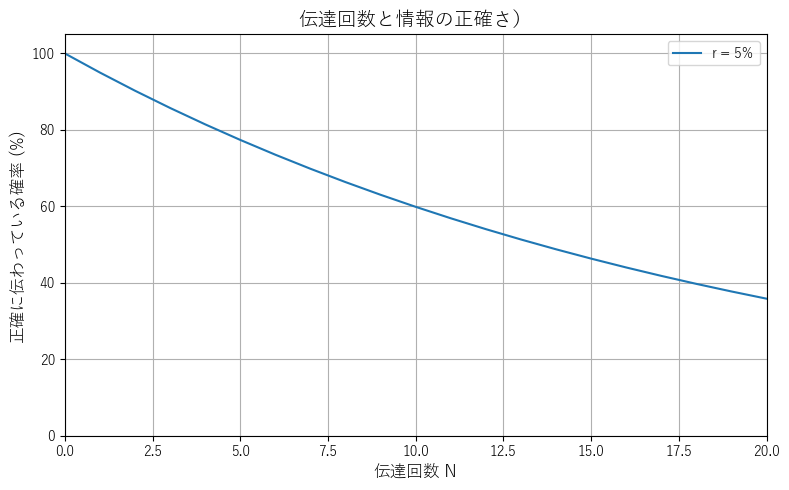

In [21]:


# ① 日本語フォントの設定（Windows想定）
#   インストール済みのフォント名を指定します。
#   例: 'MS Gothic', 'Yu Gothic', 'Meiryo' など
jp_font = 'Yu Gothic'  # 好きな日本語フォント名に変えてOK

rcParams['font.family'] = jp_font
rcParams['axes.unicode_minus'] = False  # マイナス記号の文字化け防止

# ② データ作成（伝達回数と正確に伝わっている確率）
N = np.arange(0, 21)  # 0〜20回
r_values = [0.05]  # エラー率 5%, 10%, 20%

plt.figure(figsize=(8, 5))

for r in r_values:
    # 1回の伝達で「正確に伝わる確率」を (1 - r) として、
    # N回伝達後の正確さを (1 - r)**N として計算
    prob = (1 - r) ** N * 100  # %

    label = f"r = {int(r*100)}%"
    plt.plot(N, prob, label=label)

# ③ 軸ラベル・タイトルを日本語で
plt.xlabel("伝達回数 N", fontsize=12)
plt.ylabel("正確に伝わっている確率 (%)", fontsize=12)
plt.title("伝達回数と情報の正確さ）", fontsize=14)

plt.ylim(0, 105)
plt.xlim(0, 20)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


*自己修復率を考える場合*
*自己修復率s を定義する*
*P(N) = {(1-r)+ r*s}**n*

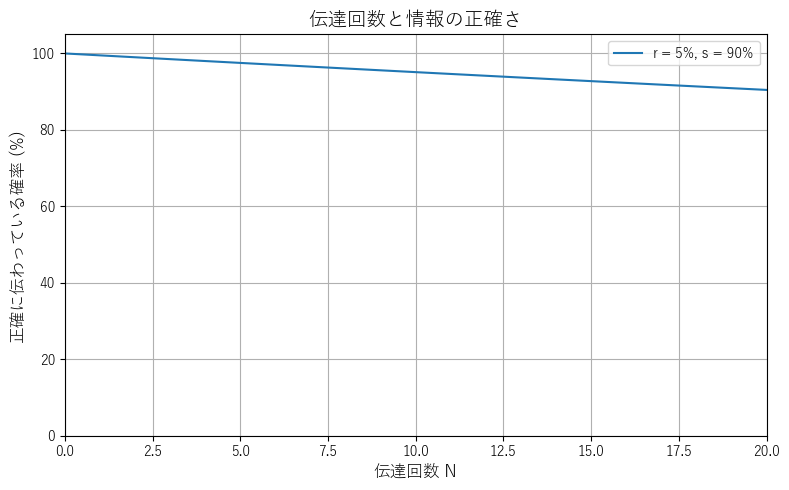

In [22]:


# ① 日本語フォントの設定（Windows想定）
#   インストール済みのフォント名を指定します。
#   例: 'MS Gothic', 'Yu Gothic', 'Meiryo' など
jp_font = 'Yu Gothic'  # 好きな日本語フォント名に変えてOK

rcParams['font.family'] = jp_font
rcParams['axes.unicode_minus'] = False  # マイナス記号の文字化け防止

# ② データ作成（伝達回数と正確に伝わっている確率）
N = np.arange(0, 21)  # 0〜20回
r_values = [0.05]  # エラー率 5%, 10%, 20%
s_values = [0.9]  # 自己修復率 5%, 10%, 20%

plt.figure(figsize=(8, 5))

for r, s in zip(r_values, s_values):

    prob = ((1 - r) + r * s) ** N * 100  # %

    label = f"r = {int(r*100)}%, s = {int(s*100)}%"
    plt.plot(N, prob, label=label)

# ③ 軸ラベル・タイトルを日本語で
plt.xlabel("伝達回数 N", fontsize=12)
plt.ylabel("正確に伝わっている確率 (%)", fontsize=12)
plt.title("伝達回数と情報の正確さ", fontsize=14)

plt.ylim(0, 105)
plt.xlim(0, 20)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


**P(N) = β(α,β+N)/β(α,β)**
**P(N) = (1-r)^n**


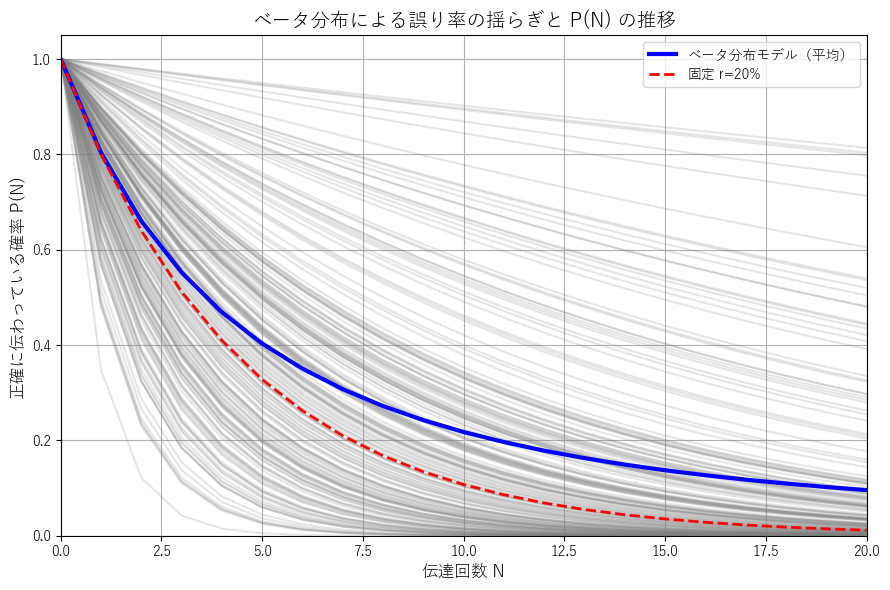

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.stats import beta

# ① 日本語フォント設定（Windows）
jp_font = 'Yu Gothic'
rcParams['font.family'] = jp_font
rcParams['axes.unicode_minus'] = False

# ② パラメータ設定
alpha = 2
beta_param = 8
N = np.arange(0, 21)  # 0〜20回

# 固定 r=0.2 のモデル
r_fixed = 0.2
P_fixed = (1 - r_fixed) ** N

# ③ ベータ分布から r をサンプリング
num_samples = 200  # r のサンプル数
r_samples = beta.rvs(alpha, beta_param, size=num_samples)

# 各 r について P(N) を計算
P_samples = np.array([(1 - r) ** N for r in r_samples])

# 平均曲線
P_mean = P_samples.mean(axis=0)

# ④ 描画
plt.figure(figsize=(9, 6))

# 個別サンプル（薄い線）
for i in range(num_samples):
    plt.plot(N, P_samples[i], color='gray', alpha=0.2)

# 平均曲線
plt.plot(N, P_mean, color='blue', linewidth=3, label="ベータ分布モデル（平均）")

# 固定 r=0.2 の曲線
plt.plot(N, P_fixed, color='red', linewidth=2, linestyle='--', label="固定 r=20%")

# 軸ラベル・タイトル
plt.xlabel("伝達回数 N", fontsize=12)
plt.ylabel("正確に伝わっている確率 P(N)", fontsize=12)
plt.title("ベータ分布による誤り率の揺らぎと P(N) の推移", fontsize=14)

plt.ylim(0, 1.05)
plt.xlim(0, 20)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


**自己修復率を加味して**

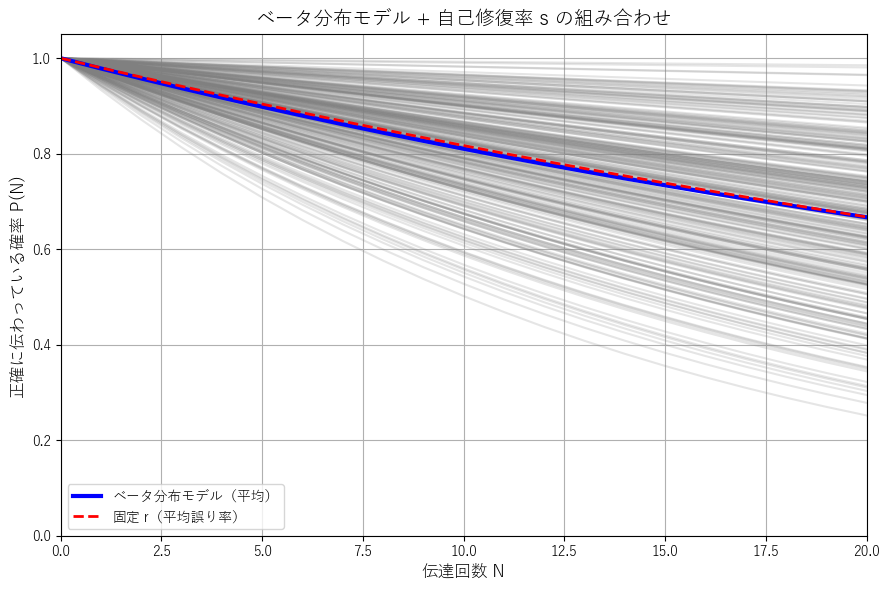

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.stats import beta

# 日本語フォント設定（Windows）
jp_font = 'Yu Gothic'
rcParams['font.family'] = jp_font
rcParams['axes.unicode_minus'] = False

# パラメータ設定
alpha = 2
beta_param = 8
s = 0.9  # 自己修復率
N = np.arange(0, 21)

# 固定 r=平均誤り率 のモデル
r_fixed = alpha / (alpha + beta_param)
P_fixed = (1 - r_fixed + r_fixed * s) ** N

# ベータ分布から r をサンプリング
num_samples = 300
r_samples = beta.rvs(alpha, beta_param, size=num_samples)

# 各 r について P(N) を計算
P_samples = np.array([(1 - r + r * s) ** N for r in r_samples])

# 平均曲線
P_mean = P_samples.mean(axis=0)

# 描画
plt.figure(figsize=(9, 6))

# 個別サンプル（薄い線）
for i in range(num_samples):
    plt.plot(N, P_samples[i], color='gray', alpha=0.2)

# 平均曲線
plt.plot(N, P_mean, color='blue', linewidth=3, label="ベータ分布モデル（平均）")

# 固定 r の曲線
plt.plot(N, P_fixed, color='red', linewidth=2, linestyle='--', label="固定 r（平均誤り率）")

plt.xlabel("伝達回数 N", fontsize=12)
plt.ylabel("正確に伝わっている確率 P(N)", fontsize=12)
plt.title("ベータ分布モデル + 自己修復率 s の組み合わせ", fontsize=14)

plt.ylim(0, 1.05)
plt.xlim(0, 20)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
